In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# Challenge 2 – Traditional CAD Pipeline (3-Class Classification)
# 0 = Melanoma, 1 = BCC, 2 = SCC

import os, cv2, pickle
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
from skimage.color import rgb2gray
from skimage.feature import local_binary_pattern
from skimage.filters import threshold_otsu
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import confusion_matrix, classification_report

# Paths

BASE = "/content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_2"
TRAIN_DIR = os.path.join(BASE, "Train")
VAL_DIR   = os.path.join(BASE, "Validation")
TEST_DIR  = os.path.join(BASE, "Test")
OUT_DIR   = os.path.join(BASE, "Results")
MODEL_PATH = os.path.join(BASE, "Models")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

MODEL_FILE = os.path.join(MODEL_PATH, "challenge2_traditional_model.pkl")
OUTPUT_CSV = os.path.join(OUT_DIR, "challenge2_predictions.csv")

# Image Reading

def read_image(path, target_size=(256,256)):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Cannot read {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    return img

# Lesion Detection / Segmentation

def detect_lesion(img):
    gray = (rgb2gray(img) * 255).astype(np.uint8)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    try:
        thr = threshold_otsu(blur)
        mask = (blur < thr).astype(np.uint8)
        coords = cv2.findNonZero(mask)
        x, y, w, h = cv2.boundingRect(coords)
        crop = img[y:y+h, x:x+w]
        crop = cv2.resize(crop, (256,256))
        return crop
    except:
        return cv2.resize(img, (256,256))

# Feature Extraction

def color_histogram_features(img, bins=(32,32,32), space='rgb'):
    if space.lower() == 'hsv':
        img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    chans = cv2.split(img)
    feats = []
    for i, ch in enumerate(chans):
        hist = cv2.calcHist([ch], [0], None, [bins[i]], [0,256]).flatten()
        hist /= (hist.sum() + 1e-9)
        feats.extend(hist.tolist())
    return np.array(feats, dtype=np.float32)

def color_moments(img):
    chans = cv2.split(img.astype(np.float32))
    feats = []
    for ch in chans:
        mean, std = ch.mean(), ch.std()
        skew = ((ch - mean)**3).mean() / (std**3 + 1e-9)
        feats.extend([mean, std, skew])
    return np.array(feats, dtype=np.float32)

def lbp_histogram(img_gray, P=8, R=7, n_bins=59):
    lbp = local_binary_pattern(img_gray, P, R, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_bins+1), range=(0, n_bins))
    hist = hist.astype("float32")
    hist /= (hist.sum() + 1e-9)
    return hist

def extract_features_for_image(path):
    img = read_image(path)
    lesion = detect_lesion(img)
    rgb_hist = color_histogram_features(lesion, (32,32,32), 'rgb')
    hsv_hist = color_histogram_features(lesion, (16,16,16), 'hsv')
    gray = (rgb2gray(lesion) * 255).astype(np.uint8)
    lbp_hist = lbp_histogram(gray)
    moments = color_moments(lesion)
    return np.concatenate([rgb_hist, hsv_hist, lbp_hist, moments])

# Dataset Loading

def load_image_paths_and_labels(base_dir, class_map):
    paths, labels = [], []
    for cname in class_map.keys():
        cdir = os.path.join(base_dir, cname)
        if not os.path.exists(cdir):
            print(f" Warning: Folder not found: {cdir}")
            continue
        lab = class_map[cname]
        for ext in ("*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG"):
            for p in glob(os.path.join(cdir, "**", ext), recursive=True):
                paths.append(p)
                labels.append(lab)
    return paths, labels

def build_features(paths):
    feats = []
    for p in tqdm(paths, desc="Extracting features"):
        feats.append(extract_features_for_image(p))
    return np.vstack(feats)

# Class Mapping

class_map = {'melanoma': 0, 'bcc': 1, 'scc': 2}

# Load Train/Val Sets

train_paths, train_labels = load_image_paths_and_labels(TRAIN_DIR, class_map)
val_paths, val_labels     = load_image_paths_and_labels(VAL_DIR, class_map)
print(" Class map used:", class_map)
print("Train:", len(train_paths), "Val:", len(val_paths))

# Feature Extraction

X_train = build_features(train_paths)
X_val   = build_features(val_paths)
y_train = np.array(train_labels)
y_val   = np.array(val_labels)

# Feature Scaling & Selection

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

selector = SelectKBest(score_func=f_classif, k=200)
X_train_sel = selector.fit_transform(X_train_s, y_train)
X_val_sel   = selector.transform(X_val_s)
print("Selected features:", X_train_sel.shape[1])

# Classification Models

rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
vote = VotingClassifier(estimators=[('rf', rf), ('gb', gb)], voting='soft', n_jobs=-1)

models = {
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "Voting Classifier": vote
}

# Train and Evaluating Each Classifier

for name, model in models.items():
    print(f"\n==============================")
    print(f"🔹 Training {name}...")
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_val_sel)

    print(f"\n {name} – Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred, labels=[0,1,2]))

    print(f"\n {name} – Classification Report:")
    print(classification_report(
        y_val, y_pred,
        labels=[0, 1, 2],
        target_names=['melanoma', 'bcc', 'scc'],
        zero_division=0
    ))

# Save the Best Model

with open(MODEL_FILE, "wb") as f:
    pickle.dump({"model": vote, "scaler": scaler, "selector": selector, "class_map": class_map}, f)
print(f"\n✅ Model saved to: {MODEL_FILE}")


✅ Class map used: {'melanoma': 0, 'bcc': 1, 'scc': 2}
Train: 5082 Val: 1270


Extracting features: 100%|██████████| 1270/1270 [06:36<00:00,  3.20it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [108 109 110 111 154 155 156 157 158 159 160 161 162 163 164 165 166 167
 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Selected features: 200

🔹 Training Random Forest...

✅ Random Forest – Confusion Matrix:
[[599  79   0]
 [ 82 415   1]
 [ 28  55  11]]

✅ Random Forest – Classification Report:
              precision    recall  f1-score   support

    melanoma       0.84      0.88      0.86       678
         bcc       0.76      0.83      0.79       498
         scc       0.92      0.12      0.21        94

    accuracy                           0.81      1270
   macro avg       0.84      0.61      0.62      1270
weighted avg       0.82      0.81      0.79      1270


🔹 Training Gradient Boosting...

✅ Gradient Boosting – Confusion Matrix:
[[593  78   7]
 [ 91 404   3]
 [ 28  57   9]]

✅ Gradient Boosting – Classification Report:
              precision    recall  f1-score   support

    melanoma       0.83      0.87      0.85       678
         bcc       0.75      0.81      0.78       498
         scc       0.47      0.10      0.16        94

    accuracy                           0.79      1270
   m

In [ ]:
# Challenge 2 – Traditional CAD Pipeline (3-Class Classification)
# 0 = Melanoma, 1 = BCC, 2 = SCC

import os, cv2, pickle
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
from collections import Counter
from skimage.color import rgb2gray
from skimage.feature import local_binary_pattern
from skimage.filters import threshold_otsu
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.multiclass import unique_labels

# Paths

BASE = "/content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_2"
TRAIN_DIR = os.path.join(BASE, "Train")
VAL_DIR   = os.path.join(BASE, "Validation")
TEST_DIR  = os.path.join(BASE, "Test")
OUT_DIR   = os.path.join(BASE, "Results")
MODEL_PATH = os.path.join(BASE, "Models")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

MODEL_FILE = os.path.join(MODEL_PATH, "challenge2_traditional_model.pkl")
OUTPUT_CSV = os.path.join(OUT_DIR, "challenge2_predictions.csv")

#  Image reading

def read_image(path, target_size=(256,256)):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Cannot read {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    return img

#  Lesion Detection / Segmentation

def detect_lesion(img):
    # Simple segmentation using Otsu thresholding on grayscale.
    gray = (rgb2gray(img) * 255).astype(np.uint8)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    try:
        thr = threshold_otsu(blur)
        mask = (blur < thr).astype(np.uint8)
        coords = cv2.findNonZero(mask)
        x, y, w, h = cv2.boundingRect(coords)
        crop = img[y:y+h, x:x+w]
        crop = cv2.resize(crop, (256,256))
        return crop
    except:
        return cv2.resize(img, (256,256))

# Feature Extraction

def color_histogram_features(img, bins=(32,32,32), space='rgb'):
    if space.lower() == 'hsv':
        img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    chans = cv2.split(img)
    feats = []
    for i, ch in enumerate(chans):
        hist = cv2.calcHist([ch], [0], None, [bins[i]], [0,256]).flatten()
        hist /= (hist.sum() + 1e-9)
        feats.extend(hist.tolist())
    return np.array(feats, dtype=np.float32)

def color_moments(img):
    chans = cv2.split(img.astype(np.float32))
    feats = []
    for ch in chans:
        mean, std = ch.mean(), ch.std()
        skew = ((ch - mean)**3).mean() / (std**3 + 1e-9)
        feats.extend([mean, std, skew])
    return np.array(feats, dtype=np.float32)

def lbp_histogram(img_gray, P=8, R=7, n_bins=59):
    lbp = local_binary_pattern(img_gray, P, R, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_bins+1), range=(0, n_bins))
    hist = hist.astype("float32")
    hist /= (hist.sum() + 1e-9)
    return hist

def extract_features_for_image(path):
    img = read_image(path)
    lesion = detect_lesion(img)
    rgb_hist = color_histogram_features(lesion, (32,32,32), 'rgb')
    hsv_hist = color_histogram_features(lesion, (16,16,16), 'hsv')
    gray = (rgb2gray(lesion) * 255).astype(np.uint8)
    lbp_hist = lbp_histogram(gray)
    moments = color_moments(lesion)
    return np.concatenate([rgb_hist, hsv_hist, lbp_hist, moments])

# Dataset loading

def load_image_paths_and_labels(base_dir, class_map):
    paths, labels = [], []
    for cname in class_map.keys():
        cdir = os.path.join(base_dir, cname)
        if not os.path.exists(cdir):
            print(f"Warning: Folder not found: {cdir}")
            continue
        lab = class_map[cname]
        for ext in ("*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG"):
            for p in glob(os.path.join(cdir, "**", ext), recursive=True):
                paths.append(p)
                labels.append(lab)
    return paths, labels

def build_features(paths):
    feats = []
    for p in tqdm(paths, desc="Extracting features"):
        feats.append(extract_features_for_image(p))
    return np.vstack(feats)

# Class mapping
# 0 = melanoma, 1 = bcc, 2 = scc
class_map = {'melanoma': 0, 'bcc': 1, 'scc': 2}

# Load train/val sets

train_paths, train_labels = load_image_paths_and_labels(TRAIN_DIR, class_map)
val_paths, val_labels     = load_image_paths_and_labels(VAL_DIR, class_map)
print("Class map used:", class_map)
print("Train:", len(train_paths), "Val:", len(val_paths))

# Feature extraction

X_train = build_features(train_paths)
X_val   = build_features(val_paths)
y_train = np.array(train_labels)
y_val   = np.array(val_labels)

# Feature Scaling

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

# Feature Selection

selector = SelectKBest(score_func=f_classif, k=200)
X_train_sel = selector.fit_transform(X_train_s, y_train)
X_val_sel   = selector.transform(X_val_s)
print("Selected features:", X_train_sel.shape[1])

# Classification

rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
clf = VotingClassifier(estimators=[('rf', rf), ('gb', gb)], voting='soft', n_jobs=-1)

print("Training classifier...")
clf.fit(X_train_sel, y_train)

# Evaluation

y_pred = clf.predict(X_val_sel)

unique_in_val = np.unique(y_val)
print(f"\nClasses present in validation set: {unique_in_val}")

print("\nConfusion matrix:")
print(confusion_matrix(y_val, y_pred, labels=[0,1,2]))

print("\nClassification report:")
print(classification_report(
    y_val, y_pred,
    labels=[0, 1, 2],
    target_names=['melanoma', 'bcc', 'scc'],
    zero_division=0
))

# Saving model

with open(MODEL_FILE, "wb") as f:
    pickle.dump({"model": clf, "scaler": scaler, "selector": selector, "class_map": class_map}, f)
print(f"Model saved to: {MODEL_FILE}")

# Test prediction

test_imgs = []
for ext in ("*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG"):
    test_imgs.extend(glob(os.path.join(TEST_DIR, "**", ext), recursive=True))
test_imgs = sorted(test_imgs)

if len(test_imgs) > 0:
    print(f"Found {len(test_imgs)} test images. Extracting features...")
    X_test = build_features(test_imgs)
    X_test_s = scaler.transform(X_test)
    X_test_sel = selector.transform(X_test_s)
    preds = clf.predict(X_test_sel)

    # Creating DataFrame in single column
    df_pred = pd.DataFrame(preds, columns=["Predicted_Label"])

    # Save as CSV
    os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
    df_pred.to_csv(OUTPUT_CSV, index=False, header=False)

    print(f"Test predictions saved to: {OUTPUT_CSV}")
    print(df_pred.head())
else:
    print("No test images found in:", TEST_DIR)


✅ Class map used: {'melanoma': 0, 'bcc': 1, 'scc': 2}
Train: 5082 Val: 1270


Extracting features: 100%|██████████| 1270/1270 [15:08<00:00,  1.40it/s]

Selected features: 200
Training classifier...



/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [108 109 110 111 154 155 156 157 158 159 160 161 162 163 164 165 166 167
 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Classes present in validation set: [0 1 2]

Confusion matrix:
[[595  80   3]
 [ 89 407   2]
 [ 29  56   9]]

Classification report:
              precision    recall  f1-score   support

    melanoma       0.83      0.88      0.86       678
         bcc       0.75      0.82      0.78       498
         scc       0.64      0.10      0.17        94

    accuracy                           0.80      1270
   macro avg       0.74      0.60      0.60      1270
weighted avg       0.79      0.80      0.78      1270

✅ Model saved to: /content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_2/Models/challenge2_traditional_model.pkl
Found 2121 test images. Extracting features...


Extracting features: 100%|██████████| 2121/2121 [05:17<00:00,  6.67it/s]


✅ Test predictions saved to: /content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_2/Results/challenge2_predictions.csv
   Predicted_Label
0                1
1                1
2                1
3                0
4                0



✅ Sample images selected:
   melanoma: /content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_2/Train/melanoma/mel01056.jpg
   bcc: /content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_2/Train/bcc/bcc01664.jpg
   scc: /content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_2/Train/scc/scc00053.jpg


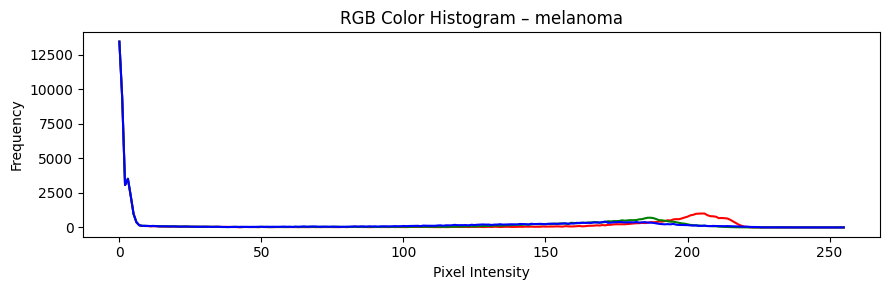

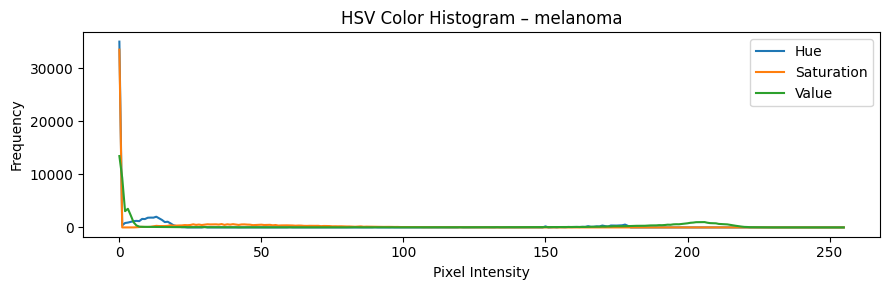

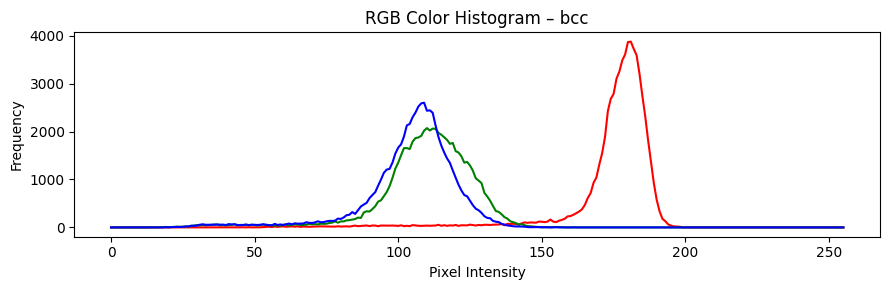

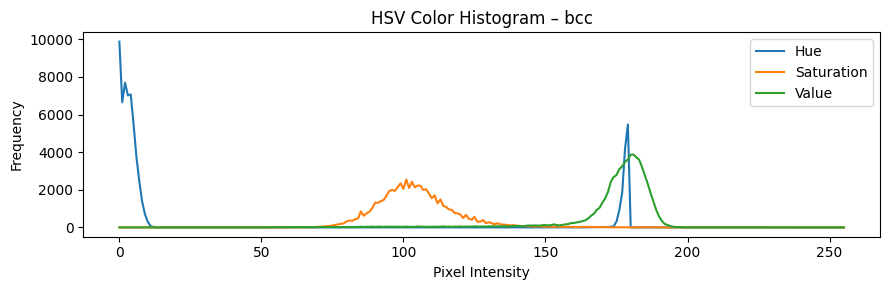

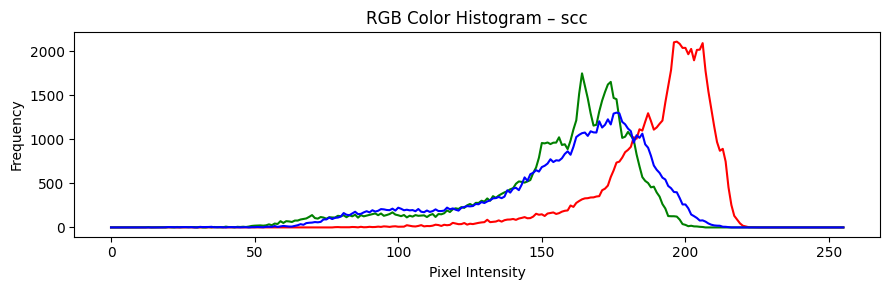

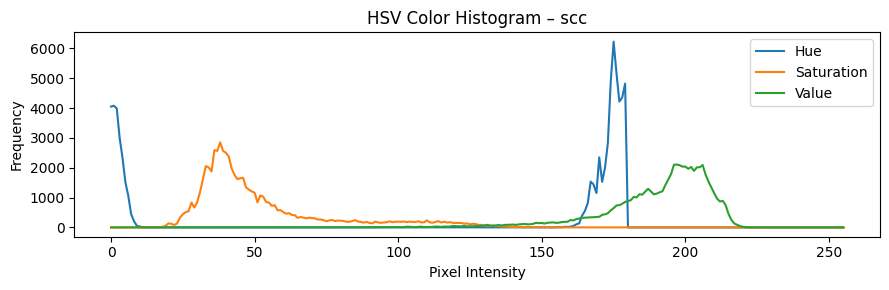

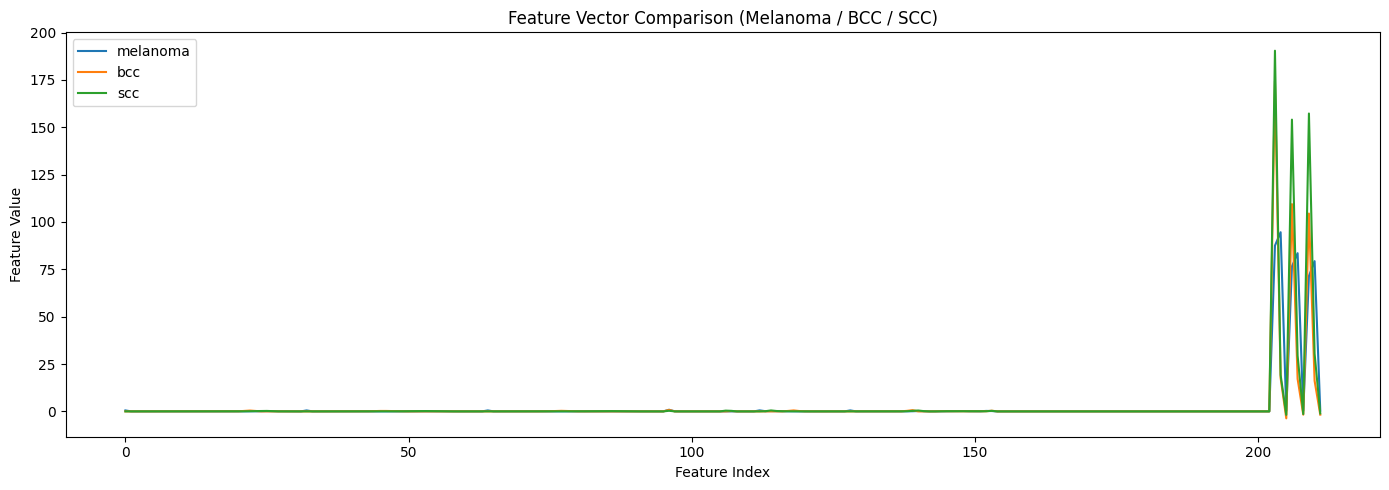


📦 Preparing boxplots for feature distributions...


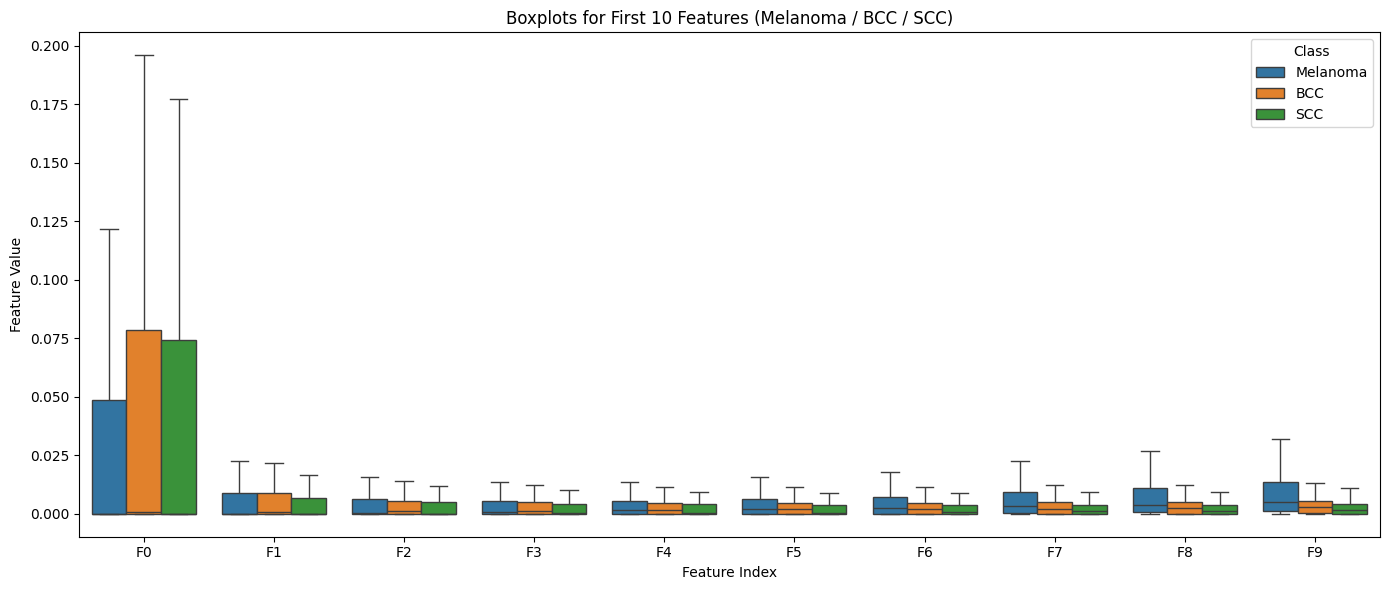


✅ All plots saved to: /content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_2/Results/Plots


In [ ]:
#  Visualization – Challenge 2 (Melanoma / BCC / SCC)

import os, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm import tqdm
from skimage.color import rgb2gray

# Paths & Directories

BASE = "/content/drive/MyDrive/MIC_UdG/CAD_Lab/Challenge_2"
TRAIN_DIR = os.path.join(BASE, "Train")
OUT_DIR = os.path.join(BASE, "Results")
PLOT_DIR = os.path.join(OUT_DIR, "Plots")
os.makedirs(PLOT_DIR, exist_ok=True)

# Class mapping

class_map = {'melanoma': 0, 'bcc': 1, 'scc': 2}

# Finding one image per class

sample_imgs = {}
for cname in class_map.keys():
    search_path = os.path.join(TRAIN_DIR, cname)
    found = glob(os.path.join(search_path, "*.jpg")) + \
            glob(os.path.join(search_path, "*.png")) + \
            glob(os.path.join(search_path, "*.jpeg"))
    if found:
        sample_imgs[cname] = found[0]

if not sample_imgs:
    raise ValueError("No training images found. Please check TRAIN_DIR path.")

print("\n Sample images selected:")
for cname, path in sample_imgs.items():
    print(f"   {cname}: {path}")

# RGB + HSV Color Histograms

def plot_color_histograms(img, title=""):
    chans = cv2.split(img)
    colors = ("r", "g", "b")

    # RGB Histogram
    plt.figure(figsize=(9,3))
    plt.title(f"RGB Color Histogram – {title}")
    for (ch, col) in zip(chans, colors):
        hist = cv2.calcHist([ch], [0], None, [256], [0,256])
        plt.plot(hist, color=col)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{title}_RGB_Hist.png"))
    plt.show()

    # HSV Histogram
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    chans_hsv = cv2.split(hsv)
    labels = ("Hue", "Saturation", "Value")
    plt.figure(figsize=(9,3))
    plt.title(f"HSV Color Histogram – {title}")
    for (ch, lbl) in zip(chans_hsv, labels):
        hist = cv2.calcHist([ch], [0], None, [256], [0,256])
        plt.plot(hist, label=lbl)
    plt.legend()
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{title}_HSV_Hist.png"))
    plt.show()

# Generating histograms for one image per class
for cname, path in sample_imgs.items():
    img = read_image(path)
    plot_color_histograms(img, title=cname)

# Feature Vector Visualization (per class)

feat_samples = {}
for cname, path in sample_imgs.items():
    feat_samples[cname] = extract_features_for_image(path)

plt.figure(figsize=(14,5))
for cname, vec in feat_samples.items():
    plt.plot(vec, label=cname)
plt.title("Feature Vector Comparison (Melanoma / BCC / SCC)")
plt.xlabel("Feature Index")
plt.ylabel("Feature Value")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Feature_Vector_Comparison.png"))
plt.show()

#  Boxplots for Feature Distributions

print("\n Preparing boxplots for feature distributions...")

# If training features exist, reuse them
if 'X_train' in locals() and 'y_train' in locals():
    X_box = X_train
    y_box = y_train
else:
    # Otherwise extract from small subset
    all_paths = []
    all_labels = []
    for cname, lid in class_map.items():
        cdir = os.path.join(TRAIN_DIR, cname)
        imgs = glob(os.path.join(cdir, "*.jpg"))[:10]
        all_paths.extend(imgs)
        all_labels.extend([lid]*len(imgs))
    X_box = np.vstack([extract_features_for_image(p) for p in tqdm(all_paths, desc="Extracting small subset")])
    y_box = np.array(all_labels)

# Taking first 10 features for boxplot readability
n_feats = 10
subset_feats = X_box[:, :n_feats]
feat_df = pd.DataFrame(subset_feats, columns=[f"F{i}" for i in range(n_feats)])
feat_df["Label"] = y_box
feat_df["Class"] = feat_df["Label"].map({0: "Melanoma", 1: "BCC", 2: "SCC"})

plt.figure(figsize=(14,6))
sns.boxplot(
    data=pd.melt(feat_df, id_vars="Class", value_vars=[f"F{i}" for i in range(n_feats)]),
    x="variable", y="value", hue="Class", orient="v", dodge=True, showfliers=False
)
plt.title("Boxplots for First 10 Features (Melanoma / BCC / SCC)")
plt.xlabel("Feature Index")
plt.ylabel("Feature Value")
plt.legend(title="Class")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Boxplot_First10Features.png"))
plt.show()

print(f"\n All plots saved to: {PLOT_DIR}")
